# Mini-projet MP1 · Un détecteur de langue anglais / français — solution de référence (exécutée)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/projets/partie_1_detecteur_langue/solution/mp1_detecteur_langue.ipynb)

La solution de référence, exécutée avec `langid.py` de ce dossier et la librairie de référence. Tes chiffres n'ont pas à être identiques : un autre découpage ou un autre lissage donnent d'autres valeurs, tout aussi justes s'ils sont bien mesurés. Le README de portfolio rédigé à partir de ces résultats est dans ce dossier (`README.md`).

**Mode rapide.** Avec `FAST_MODE = True` (la cellule de setup), 200 extraits de validation et 500 de test par langue et par longueur (1 000 et 2 000 en mode complet) ; les chiffres du README de la solution sont ceux du mode rapide.

| Étape | Contenu | ⏱️ |
|---|---|---|
| MP1.1 | Cadrer le projet et découper les textes en extraits sans fuite | 45 min |
| MP1.2 | Explorer : fréquences des lettres, entropies, table des cross-entropies | 60 min |
| MP1.3 | Modéliser : distributions lissées, log-vraisemblance, règle de Bayes avec un prior | 90 min |
| MP1.4 | Évaluer selon la longueur de l'extrait | 60 min |
| MP1.5 | Quantifier l'incertitude : intervalles de confiance bootstrap | 45 min |
| MP1.6 | Calibrer : diagramme de fiabilité, Brier, température, prior | 75 min |
| MP1.7 | Emballer : tests, figure principale, README de portfolio | 75 min |

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        conflicts = subprocess.run(["git", "-C", str(DRIVE_DIR), "diff", "--name-only", "--diff-filter=U"],
                                   capture_output=True, text=True).stdout.split()
        if conflicts:  # a file changed outside mon_travail/ AND by Claude: git leaves conflict markers in it
            print("⚠️ Tes modifications de " + ", ".join(conflicts) + " (hors de mon_travail/) entrent en conflit "
                  "avec la nouvelle version ; elles sont gardées dans `git stash`. Pour reprendre la version du "
                  "dépôt : git restore --source=HEAD --staged --worktree <fichier> (00_setup/COLAB.md, « Problèmes "
                  "fréquents »).")
        elif pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast
mylearn = wb.load_mylearn("ref")  # reference implementation

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


In [2]:
# The project folder of the reference solution
PROJECT_NAME = "partie_1_detecteur_langue"
PROJECT = ROOT / "projets" / PROJECT_NAME / "solution"
FIGURES = PROJECT / "figures"
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
import data  # noqa: E402
import langid  # noqa: E402

print("Dossier du projet :", PROJECT.relative_to(ROOT))

Dossier du projet : projets/partie_1_detecteur_langue/solution


In [3]:
# Tools of the notebook (run this cell)
import importlib
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

LENGTHS = (5, 10, 20, 50, 100, 200)          # lengths of the excerpts, in characters
N_VAL = 200 if FAST_MODE else 1000           # validation excerpts per language and per length
N_TEST = 500 if FAST_MODE else 2000          # test excerpts per language and per length
LANGS = ("en", "fr")
POSITIVE = "fr"                              # the positive class of the binary measures


def verdict(step, ok, success, failure):
    """Print ✅ with the success message, or ❌ with the failure message."""
    print(f"✅ {step} : {success}" if ok else f"❌ {step} : {failure}")
    return bool(ok)


def filled(*values):
    """True when none of the values is still `...` (or None)."""
    return all(value is not ... and value is not None for value in values)


def ready(*names):
    """True when the variables of the earlier steps exist; otherwise print which ones are missing."""
    missing = [name for name in names if name not in globals()]
    if missing:
        print(f"⏳ il manque {', '.join(missing)} : exécute d'abord les cellules des étapes précédentes, vérifications comprises (ce sont souvent elles qui créent ces variables).")
    return not missing


def fmt_int(n):
    """1234567 -> "1 234 567" (the French thousands separator, a narrow space)."""
    return f"{n:,}".replace(",", "\u202f")


def reload_langid():
    """Import your latest saved langid.py again (after each change of the file)."""
    global langid
    current = globals().get("langid")
    langid = importlib.reload(current) if current is not None else importlib.import_module("langid")
    return langid


def langid_ok():
    """Reload your langid.py; False, with the reason, when it cannot be imported yet (a syntax error...)."""
    try:
        reload_langid()
    except Exception as exc:
        print(f"⚠️ langid.py ne s'importe pas : {type(exc).__name__}: {exc}")
        return False
    return True


def run_project_tests():
    """Run the tests of the project folder (test_langid.py) and print the failures; return pytest's summary line."""
    command = [sys.executable, "-m", "pytest", str(PROJECT / "test_langid.py"), "-q", "-p", "no:cacheprovider",
               "--color=no", "-rfE", "--tb=no"]
    result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True,
                            env={**os.environ, "COLUMNS": "1000"})        # long lines: the reason of each failure
    lines = result.stdout.strip().splitlines()
    for line in [line for line in lines if line.startswith(("FAILED ", "ERROR "))][:8]:
        kind, _, rest = line.partition(" ")
        name, _, reason = rest.partition(" - ")
        where = " (erreur hors du test : import, fixture…)" if kind == "ERROR" else ""
        print(f"❌ {name.split('::')[-1]}{where}" + (f"\n   {reason[:600]}" if reason else ""))
    if any(line.startswith("ERROR ") and " - " not in line for line in lines):     # a collection error: why?
        detail = subprocess.run(command[:-1] + ["--tb=short"], cwd=ROOT, capture_output=True, text=True,
                                env={**os.environ, "COLUMNS": "1000"}).stdout.splitlines()
        for line in [line for line in detail if line.startswith("E ")][:6]:
            print("  ", line[1:].strip()[:300])
    summary = lines[-1] if lines else result.stderr.strip()[-300:]
    print("pytest:", summary)
    return summary

## MP1.1 · Cadrer le projet et découper les textes sans fuite ⏱️ 45 min

**Objectif :** des ensembles d'entraînement, de validation et de test faits de chapitres différents, et des extraits reproductibles.

a) **Cadre le problème** dans ton `README.md` (section « Le problème ») : qui utiliserait ce détecteur, sur quels textes et de quelle longueur, quelle erreur coûte le plus, quelle mesure tu suivras.
b) Lis `data.py` : `load_chapters()` coupe Holmes en 12 nouvelles et Verne en 37 chapitres ; `sample_excerpts` tire des extraits d'une longueur donnée. La cellule suivante charge les chapitres.
c) Remplis `SPLIT` : les numéros (à partir de 0) des chapitres d'entraînement, de validation et de test, pour chaque langue. Proposition : en anglais 0 à 7, 8 et 9, 10 et 11 ; en français 0 à 24, 25 à 30, 31 à 36. La validation sert à régler le modèle (la température, en MP1.6) ; le test ne sert qu'à la mesure finale.
d) Écris `make_set(part, n, seed)` (lis sa docstring) : pour chaque longueur de `LENGTHS`, `n` extraits anglais puis `n` extraits français, tirés dans les chapitres de l'ensemble `part`, avec un seul générateur.
e) Dans ton `README.md` (section « Les données ») : pourquoi découper par chapitres, au lieu de tirer les extraits de test n'importe où dans les romans ?

In [4]:
chapters = data.load_chapters()
for lang in LANGS:
    sizes = [len(chapter) for chapter in chapters[lang]]
    print(f"{lang} : {len(sizes)} chapitres, {fmt_int(sum(sizes))} caractères "
          f"(de {fmt_int(min(sizes))} à {fmt_int(max(sizes))} par chapitre)")

en : 12 chapitres, 558 325 caractères (de 37 754 à 52 772 par chapitre)
fr : 37 chapitres, 415 416 caractères (de 5 003 à 17 206 par chapitre)


In [5]:
SPLIT = {   # chapter indices (from 0) of each set, for each language
    "en": {"train": list(range(0, 8)), "val": [8, 9], "test": [10, 11]},
    "fr": {"train": list(range(0, 25)), "val": list(range(25, 31)), "test": list(range(31, 37))},
}


def make_set(part, n, seed):
    """The excerpts of one set ("val" or "test"): for every length of LENGTHS, n English then n French excerpts.

    One generator, np.random.default_rng(seed), is used for everything, in that order, with
    data.sample_excerpts on the chapters chapters[language][i] for i in SPLIT[language][part].
    Returns three lists of the same length: the texts, their labels ("en" or "fr") and their lengths.
    """
    rng = np.random.default_rng(seed)
    texts, labels, lengths = [], [], []
    for length in LENGTHS:
        for lang in LANGS:
            pool = [chapters[lang][i] for i in SPLIT[lang][part]]
            texts += data.sample_excerpts(pool, length, n, rng)
            labels += [lang] * n
            lengths += [length] * n
    return texts, labels, lengths

In [6]:
if not filled(*(SPLIT[lang][part] for lang in LANGS for part in ("train", "val", "test"))):
    print("⏳ MP1.1 : remplis SPLIT (les numéros des chapitres de chaque ensemble).")
else:
    for lang in LANGS:
        sets = [set(SPLIT[lang][part]) for part in ("train", "val", "test")]
        union = set().union(*sets)
        verdict("MP1.1", all(sets) and sum(map(len, sets)) == len(union),
                f"{lang} : trois ensembles non vides, sans chapitre commun.",
                f"{lang} : chaque ensemble doit avoir au moins un chapitre, et aucun chapitre ne doit servir deux fois.")
        verdict("MP1.1", union <= set(range(len(chapters[lang]))), f"{lang} : des numéros de chapitres valides.",
                f"{lang} : les numéros vont de 0 à {len(chapters[lang]) - 1}.")
    train_texts = [chapters[lang][i] for lang in LANGS for i in SPLIT[lang]["train"]]
    train_labels = [lang for lang in LANGS for i in SPLIT[lang]["train"]]
    with wb.attempt("MP1.1"):
        val_texts, val_labels, val_lengths = make_set("val", N_VAL, seed=7)
        test_texts, test_labels, test_lengths = make_set("test", N_TEST, seed=2026)
        verdict("MP1.1", len(test_texts) == len(test_labels) == len(test_lengths) == len(LENGTHS) * len(LANGS) * N_TEST,
                f"{fmt_int(len(test_texts))} extraits de test, {fmt_int(len(val_texts))} de validation.",
                f"il faut {N_TEST} extraits par langue et par longueur (et autant de labels et de longueurs).")
        verdict("MP1.1", all(len(t) == length for t, length in zip(test_texts, test_lengths)),
                "chaque extrait a la longueur annoncée.", "un extrait n'a pas la longueur annoncée dans test_lengths.")
        verdict("MP1.1", make_set("test", N_TEST, seed=2026)[0] == test_texts, "même graine, mêmes extraits.",
                "deux appels avec la même graine donnent des extraits différents : un seul générateur, créé dans make_set.")
        from_test = all(any(t in chapters[lang][i] for i in SPLIT[lang]["test"])
                        for t, lang in zip(test_texts, test_labels))
        verdict("MP1.1", from_test, "chaque extrait de test vient d'un chapitre de test de sa langue.",
                "un extrait de test ne vient pas des chapitres de test de sa langue : vérifie le label et SPLIT.")
        from_val = all(any(t in chapters[lang][i] for i in SPLIT[lang]["val"])
                       for t, lang in zip(val_texts, val_labels))
        verdict("MP1.1", from_val, "chaque extrait de validation vient d'un chapitre de validation de sa langue.",
                "un extrait de validation ne vient pas des chapitres de validation de sa langue : vérifie make_set.")
        print(pd.crosstab(pd.Series(test_lengths, name="longueur"), pd.Series(test_labels, name="langue")))

✅ MP1.1 : en : trois ensembles non vides, sans chapitre commun.
✅ MP1.1 : en : des numéros de chapitres valides.
✅ MP1.1 : fr : trois ensembles non vides, sans chapitre commun.
✅ MP1.1 : fr : des numéros de chapitres valides.


✅ MP1.1 : 6 000 extraits de test, 2 400 de validation.
✅ MP1.1 : chaque extrait a la longueur annoncée.


✅ MP1.1 : même graine, mêmes extraits.


✅ MP1.1 : chaque extrait de test vient d'un chapitre de test de sa langue.
✅ MP1.1 : chaque extrait de validation vient d'un chapitre de validation de sa langue.
langue     en   fr
longueur          
5         500  500
10        500  500
20        500  500
50        500  500
100       500  500
200       500  500


## MP1.2 · Explorer : fréquences des lettres, entropies, cross-entropies ⏱️ 60 min

**Objectif :** voir ce qui distingue les deux langues avant de les modéliser, avec ta librairie (`mylearn.info`).

a) Écris `letter_distribution(text)` : les probabilités des 42 lettres de `langid.ALPHABET` dans `text`, lissées avec `smoothing=1` (`mylearn.info.char_distribution`).
b) Écris `cross_entropy_table(dists)` : le tableau 2 × 2 des cross-entropies $H(p_{\text{ligne}}, p_{\text{colonne}})$, en bits, lignes et colonnes dans l'ordre de `LANGS` (`mylearn.info.cross_entropy`).
c) La vérification trace les fréquences des lettres dans les chapitres d'entraînement des deux langues, puis affiche les entropies et le tableau. Dans la cellule ✍️ qui suit la vérification : quelles lettres distinguent le mieux les deux langues ? Que mesure la case (fr, en) ? Pourquoi la diagonale est-elle la plus petite valeur de sa ligne ?

In [7]:
def letter_distribution(text):
    """Probabilities of the 42 letters of langid.ALPHABET in text (lower-cased), smoothed with smoothing=1, as an array."""
    _, probs = mylearn.info.char_distribution(text, alphabet=list(langid.ALPHABET), smoothing=1)
    return probs


def cross_entropy_table(dists):
    """2 x 2 array of H(dists[row], dists[column]) in bits, rows and columns in the order of LANGS.

    dists is a dict: language of LANGS -> its letter distribution (the output of letter_distribution).
    """
    return np.array([[mylearn.info.cross_entropy(dists[p], dists[q]) for q in LANGS] for p in LANGS])

✅ MP1.2 : deux distributions de 42 probabilités positives, de somme 1.
✅ MP1.2 : la diagonale du tableau est l'entropie de chaque langue.
✅ MP1.2 : coder une langue avec le code de l'autre coûte plus cher.
Entropies (bits par lettre) : {'en': 4.174, 'fr': 4.222}
            code en  code fr
données en    4.174    4.551
données fr    4.674    4.222


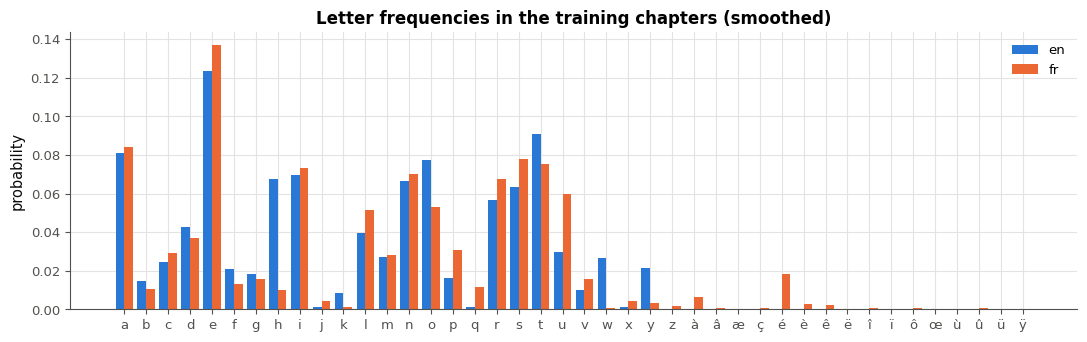

In [8]:
if ready("train_texts", "train_labels") and langid_ok():
    with wb.attempt("MP1.2"):
        dists = {lang: np.asarray(letter_distribution(" ".join(t for t, label in zip(train_texts, train_labels)
                                                               if label == lang)), dtype=float) for lang in LANGS}
        entropies = {lang: mylearn.info.entropy(dists[lang]) for lang in LANGS}
        table = np.asarray(cross_entropy_table(dists), dtype=float)
        verdict("MP1.2", all(d.shape == (42,) and np.isclose(d.sum(), 1) and (d > 0).all() for d in dists.values()),
                "deux distributions de 42 probabilités positives, de somme 1.",
                "chaque distribution doit avoir 42 probabilités strictement positives (lissage), de somme 1.")
        verdict("MP1.2", table.shape == (2, 2) and np.allclose(np.diag(table), [entropies[lang] for lang in LANGS]),
                "la diagonale du tableau est l'entropie de chaque langue.",
                "le tableau doit être 2 x 2, en bits (log₂), avec H(p, p) = H(p) sur la diagonale.")
        verdict("MP1.2", table.shape == (2, 2) and table[0, 1] > table[0, 0] and table[1, 0] > table[1, 1],
                "coder une langue avec le code de l'autre coûte plus cher.",
                "chaque case hors de la diagonale devrait dépasser la diagonale de sa ligne (la KL est positive).")
        print("Entropies (bits par lettre) :", {lang: round(h, 3) for lang, h in entropies.items()})
        print(pd.DataFrame(table, index=[f"données {lang}" for lang in LANGS],
                           columns=[f"code {lang}" for lang in LANGS]).round(3))
        fig, ax = plt.subplots(figsize=(13, 3.6))
        x = np.arange(len(langid.ALPHABET))
        for k, lang in enumerate(LANGS):
            ax.bar(x + (k - 0.5) * 0.4, dists[lang], width=0.4, label=lang)
        ax.set(xticks=x, xticklabels=list(langid.ALPHABET), ylabel="probability",
               title="Letter frequencies in the training chapters (smoothed)")
        ax.legend()
        plt.show()

✍️ **Observations (MP1.2)**

- **Les lettres qui distinguent** : les lettres accentuées, presque absentes de l'anglais (é : 1,8 % des lettres du français ; à, è, ê, ç) ; côté anglais, w (2,7 % des lettres, contre 0,05 % en français), h (6,8 % contre 1,0 %), k et y ; q et u penchent vers le français. Les plus grandes contributions à $\mathrm{KL}(p_{fr} \| p_{en})$ viennent de é, u, à et q ; celles de $\mathrm{KL}(p_{en} \| p_{fr})$, de h, w et y.
- **La case (données fr, code en)** vaut 4,674 bits : le coût moyen d'une lettre française codée avec les fréquences de l'anglais. Elle dépasse l'entropie du français (4,222) de 0,45 bit : c'est $\mathrm{KL}(p_{fr} \| p_{en})$, le surcoût d'un code fait pour l'autre langue.
- **La diagonale est la plus petite valeur de sa ligne** parce que $H(p, q) = H(p) + \mathrm{KL}(p \| q)$ et que la KL est positive, nulle seulement si $q = p$ : aucun code ne fait mieux, en moyenne, que celui de la source elle-même.

## MP1.3 · Modéliser : distributions lissées, log-vraisemblance et règle de Bayes ⏱️ 90 min

**Objectif :** écrire le cœur du détecteur, dans le module `langid.py` de ton dossier (pas dans le notebook).

Ouvre `langid.py` et écris, d'après leurs docstrings : `posterior_from_loglik`, puis `LanguageDetector.fit`, `log_likelihood`, `predict_proba` et `predict`. Quelques repères :
- `fit` estime, pour chaque langue, la distribution lissée des lettres de ses textes d'entraînement (`mylearn.info.char_distribution`) et garde leurs logarithmes dans `log_probs_` ;
- `log_likelihood` additionne, pour chaque texte, les log-probabilités de ses lettres (compter les lettres, puis un produit matriciel avec `log_probs_.T`) : c'est l'hypothèse i.i.d., les lettres traitées comme indépendantes ;
- `posterior_from_loglik` applique la règle de Bayes avec `mylearn.bayes.bayes_posterior`. Sur un texte de 200 lettres, la vraisemblance vaut environ $10^{-250}$, et bien moins pour un chapitre entier : $e^{\ell}$ donnerait 0. Retire d'abord le maximum de chaque ligne (l'astuce log-sum-exp du ch. 4) : multiplier toutes les vraisemblances par un même nombre ne change pas le posterior (4.Q7).

Enregistre `langid.py`, puis exécute la vérification : elle recharge ton module, entraîne le modèle sur les chapitres d'entraînement, l'essaie sur quelques phrases et lance tes tests (`test_langid.py`). Écris enfin la section « La méthode » de ton `README.md`.

In [9]:
if ready("train_texts", "train_labels") and langid_ok():    # langid_ok reloads your langid.py
    with wb.attempt("MP1.3"):
        model = langid.LanguageDetector().fit(train_texts, train_labels)
        demo = ["The detective lit his pipe and smiled.", "Le paquebot quitta le port à huit heures du soir.",
                "Phileas Fogg", "OK", "Merci beaucoup, see you tomorrow!"]
        for text, label, p in zip(demo, model.predict(demo), model.predict_proba(demo)):
            print(f"{label}   P(fr) = {p[1]:.3f}   {text!r}")
        verdict("MP1.3", list(model.classes_) == ["en", "fr"], "classes_ = ['en', 'fr'].",
                f"classes_ doit valoir ['en', 'fr'] (les labels triés), pas {model.classes_}.")
        verdict("MP1.3", np.allclose(np.asarray(model.predict_proba(demo)).sum(axis=1), 1),
                "les probabilités de chaque texte somment à 1.", "chaque ligne de predict_proba doit sommer à 1.")
        letters = list(model.alphabet)
        expected = [sum(model.log_probs_[k][letters.index(c)] for c in "étéx") for k in range(2)]
        verdict("MP1.3", np.allclose(model.log_likelihood(["Été, 2 x!"])[0], expected),
                "log_likelihood additionne les log-probabilités des lettres, et ignore le reste.",
                "log_likelihood(['Été, 2 x!']) doit être la somme des log-probabilités de é, t, é, x "
                "(en minuscules ; les autres caractères ignorés).")
        whole = chapters["fr"][SPLIT["fr"]["test"][0]]
        try:
            p_whole = np.asarray(model.predict_proba([whole]), dtype=float)
            no_underflow = bool(np.isfinite(p_whole).all() and p_whole[0, 1] > 0.999)
        except (ValueError, ZeroDivisionError, FloatingPointError) as exc:    # e.g. "the evidence is 0"
            no_underflow = False
            print(f"   predict_proba([un chapitre entier]) : {type(exc).__name__}: {exc}")
        verdict("MP1.3", no_underflow, f"un chapitre entier ({fmt_int(len(whole))} caractères) : pas d'underflow.",
                "sur un chapitre entier, les probabilités doivent rester finies et donner le français : "
                "retire le maximum de chaque ligne avant l'exponentielle (l'astuce log-sum-exp).")
        model.prior = [0.1, 0.9]
        verdict("MP1.3", np.allclose(model.predict_proba([""]), [[0.1, 0.9]]),
                "sans aucune lettre, le posterior est le prior.",
                "avec model.prior = [0.1, 0.9], un texte sans lettre doit recevoir [0.1, 0.9] : predict_proba doit "
                "lire self.prior à chaque appel (on change le prior après fit, sans réentraîner).")
        model.prior = None
        run_project_tests()

en   P(fr) = 0.249   'The detective lit his pipe and smiled.'
fr   P(fr) = 1.000   'Le paquebot quitta le port à huit heures du soir.'
en   P(fr) = 0.149   'Phileas Fogg'
en   P(fr) = 0.081   'OK'
en   P(fr) = 0.018   'Merci beaucoup, see you tomorrow!'
✅ MP1.3 : classes_ = ['en', 'fr'].
✅ MP1.3 : les probabilités de chaque texte somment à 1.
✅ MP1.3 : log_likelihood additionne les log-probabilités des lettres, et ignore le reste.
✅ MP1.3 : un chapitre entier (7 584 caractères) : pas d'underflow.
✅ MP1.3 : sans aucune lettre, le posterior est le prior.


pytest: 15 passed in 0.43s


## MP1.4 · Évaluer selon la longueur de l'extrait ⏱️ 60 min

**Objectif :** mesurer le détecteur sur le jeu de test, longueur par longueur, avec ta librairie (`mylearn.metrics`).

a) Écris `langid.evaluate` dans ton module (docstring), avec `mylearn.metrics` (et `mylearn.info.log_loss`) ; la classe positive est le français.
b) Écris `evaluate_by_length` ci-dessous : un tableau (DataFrame) avec une ligne par longueur, et les mesures de `langid.evaluate` en colonnes.
c) La vérification compare tes mesures à scikit-learn pour une longueur (scikit-learn sert seulement à vérifier, jamais à construire le modèle), puis affiche la matrice de confusion des extraits de 5 caractères. Dans la cellule ✍️ qui suit la vérification, puis dans le README : à partir de quelle longueur le détecteur dépasse-t-il 95 % d'accuracy ? Pourquoi les extraits courts sont-ils difficiles ? Quelle erreur domine sur 5 caractères ?

In [10]:
def evaluate_by_length(model, texts, labels, lengths):
    """DataFrame with one row per length of LENGTHS (the index) and the measures of langid.evaluate as columns."""
    lengths = np.asarray(lengths)
    rows = {}
    for length in LENGTHS:
        keep = np.flatnonzero(lengths == length)
        rows[length] = langid.evaluate(model, [texts[i] for i in keep], [labels[i] for i in keep], positive=POSITIVE)
    return pd.DataFrame.from_dict(rows, orient="index").rename_axis("length")

In [11]:
if ready("model", "test_texts") and langid_ok():
    with wb.attempt("MP1.4"):
        scores = evaluate_by_length(model, test_texts, test_labels, test_lengths)
        print(scores.round(3).to_string())
        from sklearn import metrics as skm       # only to check the numbers, never to build the model
        keep = np.flatnonzero(np.asarray(test_lengths) == 10)
        y10 = np.array([test_labels[i] for i in keep], dtype=object)
        x10 = [test_texts[i] for i in keep]
        pred10, p10 = model.predict(x10), np.asarray(model.predict_proba(x10))[:, 1]
        oracle = [skm.accuracy_score(y10, pred10), skm.f1_score(y10, pred10, pos_label="fr"),
                  skm.roc_auc_score(y10 == "fr", p10)]
        verdict("MP1.4", list(scores.index) == list(LENGTHS), "une ligne par longueur.",
                f"l'index du tableau doit être {list(LENGTHS)}.")
        verdict("MP1.4", np.allclose([scores.loc[10, "accuracy"], scores.loc[10, "f1"], scores.loc[10, "roc_auc"]], oracle),
                "accuracy, F1 et ROC-AUC à 10 caractères : les mêmes que scikit-learn.",
                f"à 10 caractères, scikit-learn trouve accuracy, F1 et ROC-AUC = {np.round(oracle, 4).tolist()}.")
        keep5 = np.flatnonzero(np.asarray(test_lengths) == 5)
        y5 = [test_labels[i] for i in keep5]
        pred5 = model.predict([test_texts[i] for i in keep5])
        cm5 = mylearn.metrics.confusion_matrix(y5, pred5, labels=["en", "fr"])
        print("\nMatrice de confusion, extraits de 5 caractères (lignes : vérité ; colonnes : prédiction)")
        print(pd.DataFrame(cm5, index=["vrai en", "vrai fr"], columns=["prédit en", "prédit fr"]))

        accuracy  precision  recall     f1  roc_auc  brier  log_loss
length                                                              
5          0.701      0.677   0.768  0.720    0.777  0.187     0.550
10         0.817      0.801   0.844  0.822    0.896  0.130     0.398
20         0.896      0.898   0.894  0.896    0.962  0.077     0.250
50         0.969      0.970   0.968  0.969    0.994  0.025     0.099
100        0.997      0.998   0.996  0.997    1.000  0.003     0.012
200        1.000      1.000   1.000  1.000    1.000  0.000     0.000


✅ MP1.4 : une ligne par longueur.
✅ MP1.4 : accuracy, F1 et ROC-AUC à 10 caractères : les mêmes que scikit-learn.

Matrice de confusion, extraits de 5 caractères (lignes : vérité ; colonnes : prédiction)
         prédit en  prédit fr
vrai en        317        183
vrai fr        116        384


✍️ **Observations (MP1.4)**

- **95 % d'accuracy** dès 50 caractères (0,969), une phrase courte ; 0,997 à 100 caractères, et aucune erreur sur les 1 000 extraits de 200 caractères.
- **Les extraits courts** n'ont que trois ou quatre lettres utiles, et chaque lettre n'apporte en moyenne que 0,4 bit pour départager les langues (les KL de MP1.2) : la plupart des lettres (e, a, s, t…) sont fréquentes dans les deux.
- **Sur 5 caractères**, l'erreur qui domine est l'anglais classé en français : 183 extraits, contre 116 français classés en anglais ; la precision du français (0,677) est donc plus basse que son recall (0,768).

## MP1.5 · Quantifier l'incertitude : intervalles de confiance bootstrap ⏱️ 45 min

**Objectif :** donner à chaque score son intervalle de confiance, et tracer la figure principale du projet.

a) Écris `bootstrap_by_length` (docstring) avec `mylearn.stats.bootstrap_ci` : pour chaque longueur, l'intervalle à 95 % de l'accuracy (sur le vecteur des bonnes réponses, 0 ou 1) et celui de la ROC-AUC (sur les lignes de `np.column_stack([y, p_fr])`, avec une statistique qui calcule `mylearn.metrics.roc_auc` des lignes tirées).
b) La vérification trace la **figure principale** : l'accuracy et la ROC-AUC selon la longueur, avec leurs intervalles, et l'enregistre dans `figures/accuracy_auc_longueur.png` (ton README l'affiche). Dans la cellule ✍️ qui suit la vérification : pourquoi l'intervalle est-il si étroit à 200 caractères ? Que dirais-tu d'une différence de 0,5 point d'accuracy entre deux versions du modèle à 10 caractères ?

In [12]:
def bootstrap_by_length(model, texts, labels, lengths, n_boot=1000, seed=0):
    """95 % bootstrap intervals of the accuracy and of the ROC-AUC, one row per length of LENGTHS (the index).

    Columns: accuracy_low, accuracy_high, auc_low, auc_high. Every interval uses
    mylearn.stats.bootstrap_ci with rng=np.random.default_rng(seed) and n_boot resamples.
    """
    lengths = np.asarray(lengths)
    rows = {}
    for length in LENGTHS:
        keep = np.flatnonzero(lengths == length)
        subset = [texts[i] for i in keep]
        y = np.array([labels[i] == POSITIVE for i in keep], dtype=float)
        p = np.asarray(model.predict_proba(subset))[:, model.classes_.index(POSITIVE)]
        right = (np.asarray(model.predict(subset), dtype=object) == np.array([labels[i] for i in keep], dtype=object))
        acc = mylearn.stats.bootstrap_ci(right.astype(float), n_boot=n_boot, rng=np.random.default_rng(seed))
        auc = mylearn.stats.bootstrap_ci(np.column_stack([y, p]),
                                         statistic=lambda rows: mylearn.metrics.roc_auc(rows[:, 0], rows[:, 1]),
                                         n_boot=n_boot, rng=np.random.default_rng(seed))
        rows[length] = {"accuracy_low": acc[0], "accuracy_high": acc[1], "auc_low": auc[0], "auc_high": auc[1]}
    return pd.DataFrame.from_dict(rows, orient="index").rename_axis("length")

        accuracy  roc_auc  accuracy_low  accuracy_high  auc_low  auc_high
length                                                                   
5          0.701    0.777         0.671          0.729    0.747     0.805
10         0.817    0.896         0.794          0.840    0.877     0.913
20         0.896    0.962         0.876          0.914    0.952     0.972
50         0.969    0.994         0.959          0.979    0.990     0.997
100        0.997    1.000         0.993          1.000    1.000     1.000
200        1.000    1.000         1.000          1.000    1.000     1.000
✅ MP1.5 : chaque intervalle contient son score.


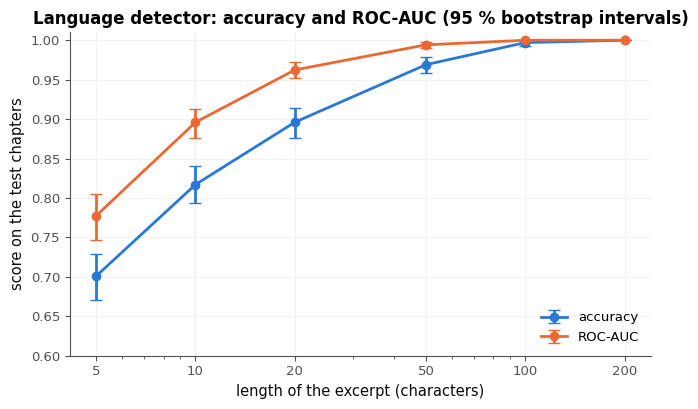

In [13]:
if ready("model", "test_texts", "scores"):
    with wb.attempt("MP1.5"):
        intervals = bootstrap_by_length(model, test_texts, test_labels, test_lengths)
        table = scores[["accuracy", "roc_auc"]].join(intervals)
        print(table.round(3).to_string())
        inside = ((table["accuracy_low"] <= table["accuracy"] + 1e-12) & (table["accuracy"] <= table["accuracy_high"] + 1e-12)
                  & (table["auc_low"] <= table["roc_auc"] + 1e-12) & (table["roc_auc"] <= table["auc_high"] + 1e-12))
        verdict("MP1.5", bool(inside.all()), "chaque intervalle contient son score.",
                "un intervalle bootstrap devrait contenir le score mesuré sur l'échantillon entier.")
        fig, ax = plt.subplots(figsize=(7.5, 4.2))
        for column, low, high, label in [("accuracy", "accuracy_low", "accuracy_high", "accuracy"),
                                         ("roc_auc", "auc_low", "auc_high", "ROC-AUC")]:
            yerr = np.vstack([table[column] - table[low], table[high] - table[column]]).clip(min=0)
            ax.errorbar(table.index, table[column], yerr=yerr, marker="o", capsize=4, label=label)
        ax.set_xscale("log")
        ax.set(xticks=list(LENGTHS), xticklabels=[str(n) for n in LENGTHS], ylim=(0.6, 1.01),
               xlabel="length of the excerpt (characters)", ylabel="score on the test chapters",
               title="Language detector: accuracy and ROC-AUC (95 % bootstrap intervals)")
        ax.grid(True, alpha=0.4)
        ax.legend(loc="lower right")
        FIGURES.mkdir(exist_ok=True)
        fig.savefig(FIGURES / "accuracy_auc_longueur.png", dpi=110, bbox_inches="tight")
        plt.show()

✍️ **Observations (MP1.5)**

- **À 200 caractères**, le détecteur ne se trompe sur aucun des 1 000 extraits : tous les rééchantillons ont une accuracy de 1, et l'intervalle percentile se réduit à [1 ; 1]. Ce n'est pas une certitude : avec 0 erreur sur $n$ essais, la « règle de trois » borne le taux d'erreur à $3/n$, soit 0,3 % avec 95 % de confiance (une accuracy d'au moins 0,997), si les extraits étaient indépendants ; ils viennent de quelques chapitres et se chevauchent, donc cette borne, comme tous les intervalles du projet, est optimiste.
- **À 10 caractères**, l'intervalle de l'accuracy va de 0,794 à 0,840, environ ±2,3 points. Comparé à ces ±2,3 points, un écart de 0,5 point entre deux versions ne permet pas de conclure à lui seul ; pour trancher, on évalue les deux versions sur les mêmes extraits et l'on bootstrappe la différence (un rééchantillonnage apparié, que tu pratiqueras au ch. 8), dont l'intervalle est bien plus étroit.

## MP1.6 · Calibrer : diagramme de fiabilité, Brier, température et prior ⏱️ 75 min

**Objectif :** vérifier que les probabilités du détecteur sont honnêtes, et les corriger si besoin.

a) Écris `langid.fit_temperature` dans ton module (docstring) : la température $T$ qui minimise la log loss sur la **validation**, par descente de gradient sur $\log T$ (`mylearn.calculus`).
b) Écris `reliability_data(model, texts, labels)` ci-dessous : les données du diagramme de fiabilité de $P(\text{fr})$ (`mylearn.metrics.calibration_curve`, 10 intervalles) et le score de Brier.
c) La vérification ajuste $T$ sur la validation, compare le Brier et la log loss du test avant et après, et enregistre les deux diagrammes dans `figures/fiabilite.png`.
d) **Le prior.** Sur un site francophone, 90 % des messages sont en français. La vérification évalue les extraits de 10 caractères dans cette proportion, avec le prior uniforme puis avec le prior $[0{,}1 ;\ 0{,}9]$.

Dans la cellule ✍️ qui suit la vérification, puis dans le README : le modèle était-il trop sûr de lui, ou pas assez ? Que change la température aux décisions ? Pourquoi le prior compte-t-il beaucoup à 10 caractères, et presque plus à 200 ?

In [14]:
def reliability_data(model, texts, labels):
    """(prob_true, prob_pred, brier) of P(fr) on (texts, labels), with mylearn.metrics (10 bins)."""
    y = np.array([label == POSITIVE for label in labels], dtype=int)
    p = np.asarray(model.predict_proba(texts))[:, model.classes_.index(POSITIVE)]
    prob_true, prob_pred = mylearn.metrics.calibration_curve(y, p, n_bins=10)
    return prob_true, prob_pred, mylearn.metrics.brier_score(y, p)

✅ MP1.6 : predict_proba tient compte de model.temperature.


✅ MP1.6 : T = 1.243 minimise la log loss de validation.


                  Brier (test)  log loss (test, nats)  accuracy (test)
avant (T = 1)           0.0704                 0.2181           0.8967
après (T = 1.24)        0.0707                 0.2179           0.8967
✅ MP1.6 : avec le prior uniforme, la température ne change aucune décision.


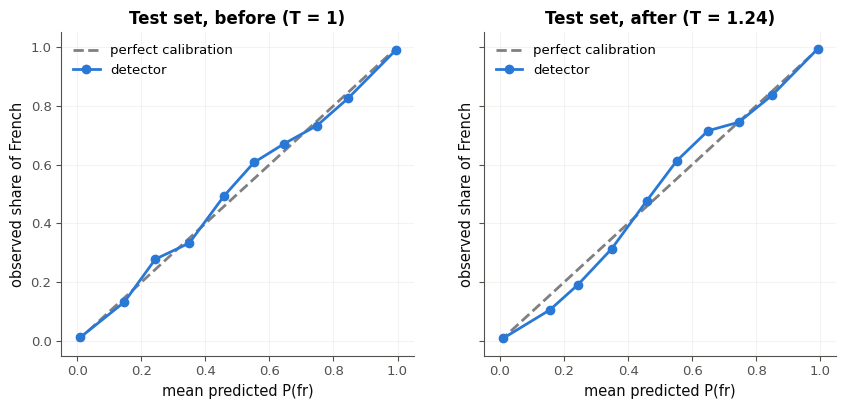


Un site francophone, extraits de 10 caractères (500 en français, 55 en anglais)
toujours « fr » : accuracy 0.901 (la référence à battre)
prior uniforme : accuracy 0.836, Brier 0.1368
prior [0.1, 0.9] : accuracy 0.923, Brier 0.0603
✅ MP1.6 : le prior change les probabilités.


In [15]:
if ready("model", "val_texts", "test_texts") and langid_ok():
    with wb.attempt("MP1.6"):
        y_val = np.array([label == POSITIVE for label in val_labels], dtype=int)
        y_test = np.array([label == POSITIVE for label in test_labels], dtype=int)

        def log_loss_at(temperature, texts, y):
            model.temperature = temperature
            return mylearn.info.log_loss(y, np.asarray(model.predict_proba(texts))[:, 1])

        probe = val_texts[:50]
        model.temperature = 2.0
        p_hot = np.asarray(model.predict_proba(probe), dtype=float)
        model.temperature = 1.0
        uses_t = verdict("MP1.6", not np.allclose(p_hot, np.asarray(model.predict_proba(probe), dtype=float)),
                         "predict_proba tient compte de model.temperature.",
                         "changer model.temperature ne change pas les probabilités : predict_proba doit lire "
                         "self.temperature à chaque appel (la température se règle après fit, sans réentraîner).")
        T = langid.fit_temperature(model, val_texts, val_labels)
        around = [log_loss_at(t, val_texts, y_val) for t in (T / 1.1, T, T * 1.1)]
        verdict("MP1.6", uses_t and T > 0 and around[1] <= min(around[0], around[2]) + 1e-9,
                f"T = {T:.3f} minimise la log loss de validation.",
                f"T = {T!r} ne minimise pas la log loss de validation : vérifie la descente sur log T.")
        rows = {}
        curves = {}
        for name, temperature in [("avant (T = 1)", 1.0), (f"après (T = {T:.2f})", T)]:
            model.temperature = temperature
            prob_true, prob_pred, brier = reliability_data(model, test_texts, test_labels)
            curves[name] = (prob_pred, prob_true)
            rows[name] = {"Brier (test)": brier, "log loss (test, nats)": log_loss_at(temperature, test_texts, y_test),
                          "accuracy (test)": float(np.mean(model.predict(test_texts) == np.array(test_labels, dtype=object)))}
        print(pd.DataFrame(rows).T.round(4).to_string())
        verdict("MP1.6", rows[f"après (T = {T:.2f})"]["accuracy (test)"] == rows["avant (T = 1)"]["accuracy (test)"],
                "avec le prior uniforme, la température ne change aucune décision.",
                "avec le prior uniforme, la température ne devrait changer aucune décision.")
        fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
        for ax, (name, (prob_pred, prob_true)) in zip(axes, curves.items()):
            ax.plot([0, 1], [0, 1], ls="--", color="0.5", label="perfect calibration")
            ax.plot(prob_pred, prob_true, marker="o", label="detector")
            ax.set(title=f"Test set, {name.replace('avant', 'before').replace('après', 'after')}",
                   xlabel="mean predicted P(fr)", ylabel="observed share of French")
            ax.grid(True, alpha=0.4)
            ax.legend(loc="upper left")
        FIGURES.mkdir(exist_ok=True)
        fig.savefig(FIGURES / "fiabilite.png", dpi=110, bbox_inches="tight")
        plt.show()
        # d) A French website: 9 French excerpts for 1 English one, at 10 characters
        model.temperature = T
        keep10 = np.flatnonzero(np.asarray(test_lengths) == 10)
        fr10 = [test_texts[i] for i in keep10 if test_labels[i] == "fr"]
        en10 = [test_texts[i] for i in keep10 if test_labels[i] == "en"][: len(fr10) // 9]
        site_texts, site_y = fr10 + en10, np.array([1] * len(fr10) + [0] * len(en10))
        print(f"\nUn site francophone, extraits de 10 caractères ({len(fr10)} en français, {len(en10)} en anglais)")
        print(f"toujours « fr » : accuracy {np.mean(site_y == 1):.3f} (la référence à battre)")
        p_by_prior = []
        for prior in (None, [0.1, 0.9]):
            model.prior = prior
            p_site = np.asarray(model.predict_proba(site_texts))[:, 1]
            p_by_prior.append(p_site)
            print(f"prior {prior or 'uniforme'} : accuracy {np.mean((p_site > 0.5) == site_y):.3f}, "
                  f"Brier {mylearn.metrics.brier_score(site_y, p_site):.4f}")
        model.prior = None
        verdict("MP1.6", not np.allclose(*p_by_prior), "le prior change les probabilités.",
                "le prior n'a rien changé : predict_proba doit lire self.prior à chaque appel.")

✍️ **Observations (MP1.6)**

- **T ≈ 1,24 > 1** : diviser les log-vraisemblances par 1,24 adoucit les probabilités ; sur la validation, le modèle était donc un peu trop sûr de lui, ce qui va dans le sens attendu pour un modèle naïf (l'hypothèse i.i.d. compte plusieurs fois des indices liés), sans plus. Mais l'effet est minuscule sur le test (Brier de 0,0704 à 0,0707, log loss de 0,2181 à 0,2179) et dépend des chapitres de validation : un autre découpage peut donner $T < 1$. Une seule température pour toutes les longueurs est un compromis.
- **Les décisions** ne changent pas : avec le prior uniforme, diviser les deux log-vraisemblances par le même $T > 0$ ne change pas la plus grande. Seules les probabilités bougent, donc le Brier et la log loss.
- **Le prior** [0,1 ; 0,9] pèse $\ln 9 \approx 2{,}2$ nats en faveur du français. À 10 caractères, l'écart des log-vraisemblances est du même ordre (environ 0,3 nat par lettre) : le prior décide souvent, et l'accuracy passe de 0,836 à 0,923, au-dessus de la référence « toujours français » (0,901), que le prior uniforme ne battait pas. À 200 caractères, l'écart vaut des dizaines de nats : le prior ne pèse presque plus rien.

## MP1.7 · Emballer : tests, figure principale, README de portfolio ⏱️ 75 min

**Objectif :** un projet qu'un recruteur peut lire et relancer.

a) **Les tests** : complète `test_langid.py` jusqu'à au moins **six** tests, tous verts (les idées sont dans l'en-tête du fichier) ; chaque message d'échec dit ce qui était attendu.
b) **Le README** (`README.md` de ton dossier) : remplace chaque paragraphe « TODO » par ton texte et tes chiffres (MP1.4 à MP1.6, et tes observations), avec la figure principale ; ajoute les limites et les pistes. Tu peux l'écrire en anglais, avec le même plan.
c) **La propreté** : redémarre le noyau et exécute tout le notebook (il doit aller au bout en quelques minutes), relis les sorties, puis enregistre ton travail avec git, par exemple :

```bash
git add mon_travail/projets/partie_1_detecteur_langue
git commit -m "MP1: language detector EN/FR from scratch"
```

La vérification ci-dessous lance tes tests et relit ton README. Ensuite : la grille d'évaluation du cahier des charges, puis, seulement après, la solution de référence (`projets/partie_1_detecteur_langue/solution/`).

In [16]:
if ready("scores", "intervals", "T"):
    summary = run_project_tests()
    passed = int(re.search(r"(\d+) passed", summary).group(1)) if re.search(r"(\d+) passed", summary) else 0
    clean = not re.search(r"failed|error", summary)
    verdict("MP1.7", clean and passed >= 6, f"{passed} tests, tous verts.",
            f"il faut au moins 6 tests, tous verts ({passed} vert(s) pour l'instant).")
    readme_path = PROJECT / "README.md"
    readme = readme_path.read_text(encoding="utf-8") if readme_path.exists() else ""
    headers = [h.lower() for h in re.findall(r"(?m)^#{2,}\s+(.*)$", readme)]
    SECTIONS = {"Le problème": ("problème", "probleme", "problem"),     # a README in English is welcome
                "Les données": ("données", "donnees", "data"),
                "La méthode": ("méthode", "methode", "method"),
                "Les résultats": ("résultat", "resultat", "result"),
                "Les limites": ("limite", "limit")}
    for section, keywords in SECTIONS.items():
        found = any(word in header for header in headers for word in keywords)
        verdict("MP1.7", found, f"README : section « {section} ».",
                f"README : il manque une section « ## {section} » (ou en anglais, « ## {keywords[-1].capitalize()}… »).")
    todo = re.findall(r"(?m)^\W*TODO\b", readme)
    verdict("MP1.7", readme and not todo, "README : plus aucun paragraphe « TODO ».",
            f"README : {len(todo)} paragraphe(s) commencent encore par « TODO » : remplace-les par ton texte.")
    verdict("MP1.7", "figures/accuracy_auc_longueur.png" in readme and (FIGURES / "accuracy_auc_longueur.png").exists(),
            "README : la figure principale est là.",
            "README : affiche figures/accuracy_auc_longueur.png (créée en MP1.5).")
    verdict("MP1.7", (FIGURES / "fiabilite.png").exists(), "le diagramme de fiabilité est enregistré.",
            "il manque figures/fiabilite.png (créée en MP1.6).")

pytest: 15 passed in 0.50s
✅ MP1.7 : 15 tests, tous verts.
✅ MP1.7 : README : section « Le problème ».
✅ MP1.7 : README : section « Les données ».
✅ MP1.7 : README : section « La méthode ».
✅ MP1.7 : README : section « Les résultats ».
✅ MP1.7 : README : section « Les limites ».
✅ MP1.7 : README : plus aucun paragraphe « TODO ».
✅ MP1.7 : README : la figure principale est là.
✅ MP1.7 : le diagramme de fiabilité est enregistré.


## ✅ Bilan

**Grille d'évaluation** (sur 20, détaillée dans le cahier des charges) : découpage sans fuite (2) · modèle (4) · évaluation selon la longueur (4) · incertitude (2) · calibration (3) · code professionnel (3) · README (2).

**Pour aller plus loin** : les extensions du cahier des charges (bigrammes de caractères, troisième langue, comparaison avec `MultinomialNB` après le ch. 13, ou avec un détecteur pré-entraîné). La suite du workbook : la partie II, où l'on apprend à classer, à découper les données et à combattre l'overfitting.